# 8. Как Graph-EVT-agent проходит путь от данных к источнику

Этот ноутбук **исполняет**, а не имитирует, `GraphEVTPipeline` на многоканальном наборе `kuramoto_propagation_series.csv`. Он показывает три разные сущности:

1. **план конвейера** — маршрут, завершённые этапы и причина остановки;
2. **граф зависимостей** — сеть каналов, оценённая только по baseline;
3. **опциональная модель процесса** — обученные GNN/GAT scores и episode-specific attention, если в pipeline передан fitted `GraphProcessModel`.

В этом примере learned-модель не передаётся: ноутбук показывает базовый маршрут inspect → EVT → graph → ranking. Обучение GNN/GAT на независимых размеченных эпизодах вынесено в ноутбук 09. Ни рейтинг, ни attention не доказывают причинность.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from graph_evt_agent import EVTConfig, GraphConfig, GraphEVTPipeline, InputConfig

SEED = 42
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/kuramoto_propagation_series.csv").exists())
DATA_PATH = ROOT / "data/generated/kuramoto_propagation_series.csv"

dataframe = pd.read_csv(DATA_PATH)
time_column = "timestamp"
channel_names = [column for column in dataframe.columns if column.startswith("channel_")]
timestamps = dataframe[time_column].to_numpy()
values = dataframe[channel_names].to_numpy()
event_mask = dataframe["is_extreme"].to_numpy(dtype=bool)
propagation_metadata = json.loads((ROOT / "data/generated/synthetic_datasets_metadata.json").read_text())["kuramoto_propagation"]
event_onset = int(np.flatnonzero(event_mask)[0])
true_source_name = channel_names[int(propagation_metadata["source_channel"])]
print(f"data: {values.shape[0]} time points × {values.shape[1]} channels")
dataframe.head()

data: 1500 time points × 12 channels


,timestamp,channel_00,channel_01,channel_02,channel_03,channel_04,channel_05,channel_06,channel_07,channel_08,channel_09,channel_10,channel_11,is_extreme
0,0.00,0.988693,-0.374667,0.776099,0.945816,-0.557801,0.152571,0.997552,0.974436,-0.720804,-0.306710,-0.725527,0.444082,0
1,0.02,0.984541,-0.351546,0.762909,0.952327,-0.572107,0.137739,0.995610,0.969502,-0.731884,-0.286965,-0.709036,0.428116,0
2,0.04,0.979750,-0.328181,0.749399,0.958435,-0.586221,0.122883,0.993106,0.964138,-0.742757,-0.267081,-0.692133,0.412022,0
3,0.06,0.974322,-0.304585,0.735575,0.964137,-0.600141,0.108007,0.990044,0.958349,-0.753420,-0.247063,-0.674827,0.395806,0
4,0.08,0.968263,-0.280772,0.721442,0.969429,-0.613862,0.093114,0.986424,0.952136,-0.763872,-0.226921,-0.657127,0.379471,0


## 1. Исполняемый граф конвейера

`run_detailed` сначала валидирует вход и формирует детерминированный план действий. EVT-порог оценивается **только на baseline**. Одномерные данные или отсутствие тревоги завершают маршрут без графа. Для обнаруженного многоканального события граф также строится только по baseline, после чего каналы ранжируются по раннему и сильному отклику с учётом соседей. Если передан fitted process model, после ranking выполняются GNN/GAT-инференс и attention; иначе pipeline возвращает прозрачный ranking.

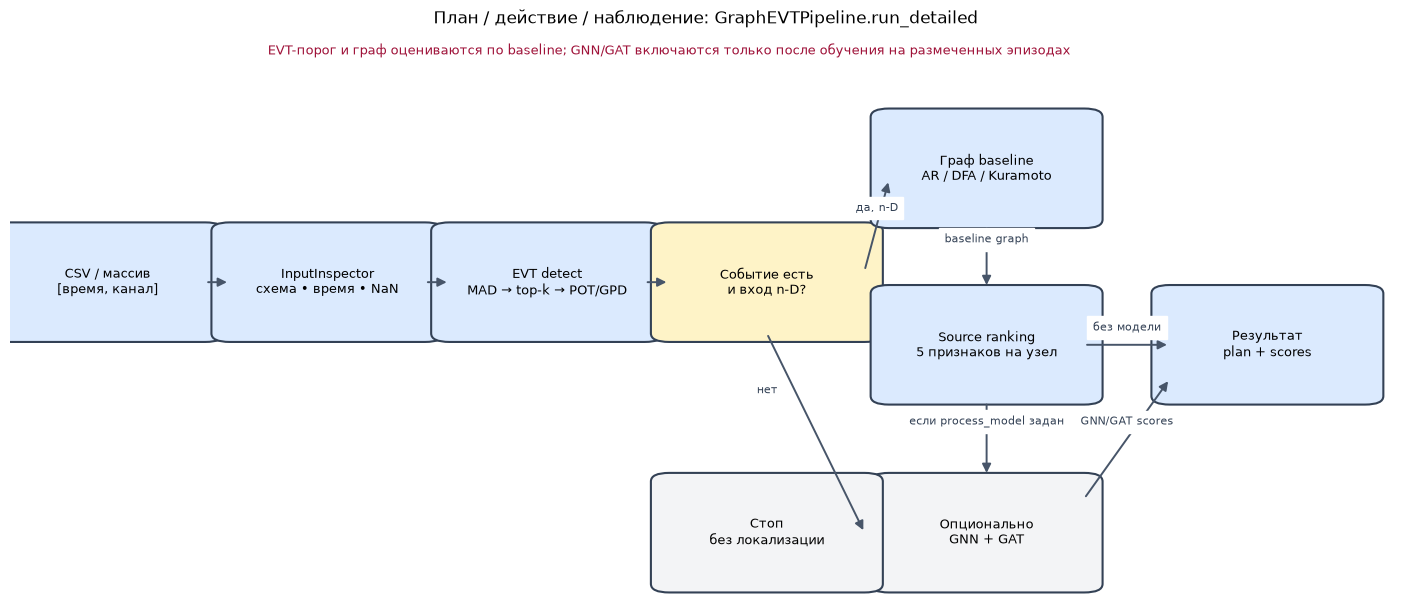

In [2]:
stages = {
    "input": (0.08, 0.56, "CSV / массив\n[время, канал]"),
    "inspect": (0.26, 0.56, "InputInspector\nсхема • время • NaN"),
    "evt": (0.44, 0.56, "EVT detect\nMAD → top-k → POT/GPD"),
    "decision": (0.62, 0.56, "Событие есть\nи вход n-D?"),
    "graph": (0.80, 0.76, "Граф baseline\nAR / DFA / Kuramoto"),
    "rank": (0.80, 0.45, "Source ranking\n5 признаков на узел"),
    "learned": (0.80, 0.12, "Опционально\nGNN + GAT"),
    "stop": (0.62, 0.12, "Стоп\nбез локализации"),
    "output": (1.03, 0.45, "Результат\nplan + scores"),
}
edges = [
    ("input", "inspect", ""), ("inspect", "evt", ""),
    ("evt", "decision", ""), ("decision", "graph", "да, n-D"),
    ("graph", "rank", "baseline graph"),
    ("decision", "stop", "нет"),
    ("rank", "learned", "если process_model задан"),
    ("rank", "output", "без модели"),
    ("learned", "output", "GNN/GAT scores"),
]
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
for key, (x, y, label) in stages.items():
    width, height = (0.16, 0.18)
    color = "#dbeafe" if key not in {"decision", "stop", "learned"} else ("#fef3c7" if key == "decision" else "#f3f4f6")
    box = FancyBboxPatch((x-width/2, y-height/2), width, height,
                         boxstyle="round,pad=0.015", facecolor=color,
                         edgecolor="#334155", linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, label, ha="center", va="center", fontsize=9)
for start, end, label in edges:
    x1, y1, _ = stages[start]; x2, y2, _ = stages[end]
    if start == "decision":
        source = (x1 + 0.08, y1 + 0.02) if end == "graph" else (x1, y1 - 0.09)
        target = (x2 - 0.08, y2 - 0.02) if end == "graph" else (x2 + 0.08, y2)
    elif start == "graph":
        source, target = (x1, y1 - 0.10), (x2, y2 + 0.10)
    elif start == "rank" and end == "learned":
        source, target = (x1, y1 - 0.10), (x2, y2 + 0.10)
    elif start == "learned":
        source, target = (x1 + 0.08, y1 + 0.06), (x2 - 0.08, y2 - 0.06)
    else:
        source, target = (x1 + 0.08, y1), (x2 - 0.08, y2)
    arrow = FancyArrowPatch(source, target, arrowstyle="-|>", mutation_scale=13,
                            linewidth=1.4, color="#475569",
                            connectionstyle="arc3,rad=0.0")
    ax.add_patch(arrow)
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.025, label, fontsize=8,
                color="#334155", backgroundcolor="white", ha="center")
ax.text(0.54, 0.96, "EVT-порог и граф оцениваются по baseline; GNN/GAT включаются только после обучения на размеченных эпизодах",
        ha="center", fontsize=9, color="#9f1239")
ax.set(xlim=(0, 1.14), ylim=(0, 1), title="План / действие / наблюдение: GraphEVTPipeline.run_detailed")
ax.axis("off")
plt.show()

## 2. Запуск на данных

Baseline заканчивается точно перед известным onset (`event_onset` из метаданных генератора) — oracle-assisted выбор, допустимый только потому, что этот ряд синтетический. Метод `ar` строит ребро по абсолютной корреляции инноваций отдельных AR-моделей. `persistence=1` — минимальное требование устойчивости, подобранное в ноутбуке 5 как конфигурация, которая на этом ряде и обнаруживает событие, и верно локализует источник.

In [3]:
BASELINE_SIZE = event_onset
pipeline = GraphEVTPipeline(
    EVTConfig(
        baseline_size=BASELINE_SIZE,
        tail_quantile=0.85,
        alarm_probability=0.97,
        top_k=3,
        persistence=1,
    ),
    graph=GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
    input_config=InputConfig(missing="error", require_regular_time=True),
    verbose=True,
)
result = pipeline.run_detailed(dataframe.set_index(time_column)[channel_names])
plan = result.plan
estimated_source = None if result.ranking is None else channel_names[result.ranking.source]

summary = pd.Series({
    "route": result.input_profile.kind,
    "time points": result.input_profile.n_time,
    "channels": result.input_profile.n_channels,
    "detected": result.detection.detected,
    "alarm index": result.detection.time_index,
    "alarm threshold": result.detection.alarm_threshold,
    "graph method": None if result.graph is None else result.graph.method,
    "true source": true_source_name,
    "estimated source": estimated_source,
    "source correct": estimated_source == true_source_name,
    "planner route": None if plan is None else plan.route,
    "completed actions": None if plan is None else " -> ".join(plan.completed_actions),
    "stop reason": None if plan is None else plan.stop_reason,
}, name="pipeline output")
summary.to_frame()

Graph-EVT pipeline:   0%|          | 0/5 [00:00<?, ?it/s]

,pipeline output
route,multivariate
time points,1500
channels,12
detected,True
alarm index,949
alarm threshold,1.076386
graph method,ar_innovation_correlation
true source,channel_00
estimated source,channel_00
source correct,True


## 3. Связь входа, EVT-решения и ответа

На рисунке ниже вертикальная линия отделяет baseline. EVT-индикатор — среднее трёх наибольших абсолютных robust z-score в каждый момент. Первое устойчивое превышение красного порога запускает графовую локализацию. Вероятности справа нормированы внутри эвристического ranking и не являются калиброванными вероятностями физической причины.

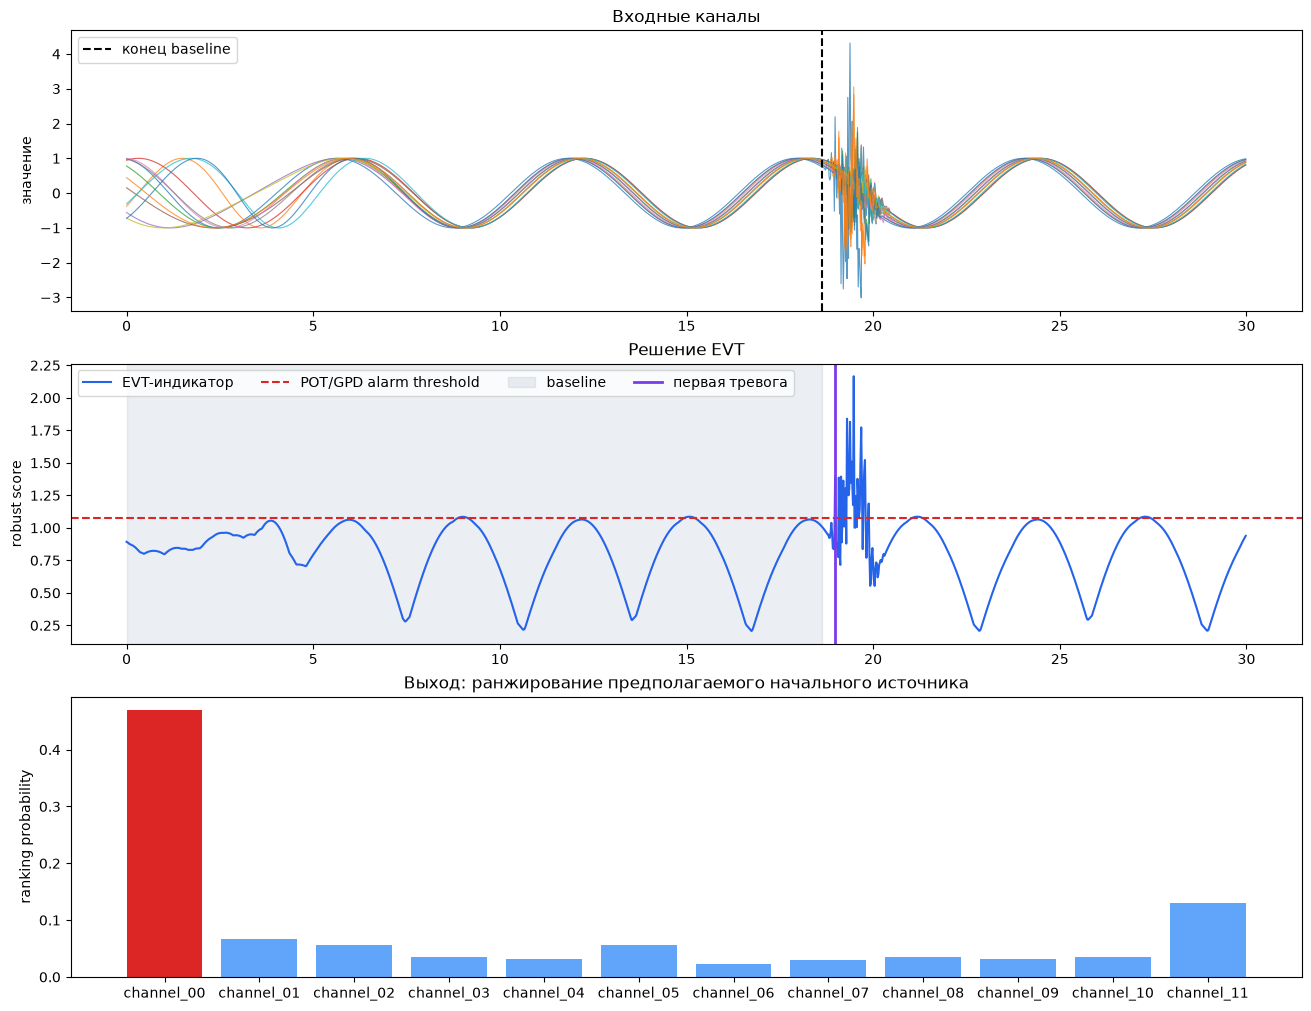

In [4]:
detection = result.detection
fig, axes = plt.subplots(3, 1, figsize=(13, 10), constrained_layout=True)

axes[0].plot(timestamps, values, alpha=0.75, linewidth=0.8)
axes[0].axvline(timestamps[BASELINE_SIZE], color="black", linestyle="--", label="конец baseline")
axes[0].set(title="Входные каналы", ylabel="значение")
axes[0].legend(loc="upper left", ncol=2)

axes[1].plot(timestamps, detection.indicator, color="#2563eb", label="EVT-индикатор")
axes[1].axhline(detection.alarm_threshold, color="#dc2626", linestyle="--", label="POT/GPD alarm threshold")
axes[1].axvspan(timestamps[0], timestamps[BASELINE_SIZE-1], color="#94a3b8", alpha=0.18, label="baseline")
if detection.time_index is not None:
    axes[1].axvline(timestamps[detection.time_index], color="#7c3aed", linewidth=2, label="первая тревога")
axes[1].set(title="Решение EVT", ylabel="robust score")
axes[1].legend(loc="upper left", ncol=4)

if result.ranking is not None:
    probabilities_by_node = np.zeros(len(channel_names))
    probabilities_by_node[result.ranking.node_ids] = result.ranking.probabilities
    colors = ["#dc2626" if node == result.ranking.source else "#60a5fa" for node in range(len(channel_names))]
    axes[2].bar(channel_names, probabilities_by_node, color=colors)
    axes[2].set(title="Выход: ранжирование предполагаемого начального источника", ylabel="ranking probability")
else:
    axes[2].text(0.5, 0.5, "Локализация пропущена: нет обнаруженного n-D события", ha="center", va="center")
    axes[2].set_axis_off()
plt.show()

## 4. Оценённый граф зависимостей

Узел — канал, линия — ребро, прошедшее порог зависимости на baseline. Толщина и непрозрачность кодируют оценённую силу связи. Красный узел — первый в ranking. Самосвязи не рисуются. Этот граф описывает статистическую зависимость baseline и не задаёт направление распространения.

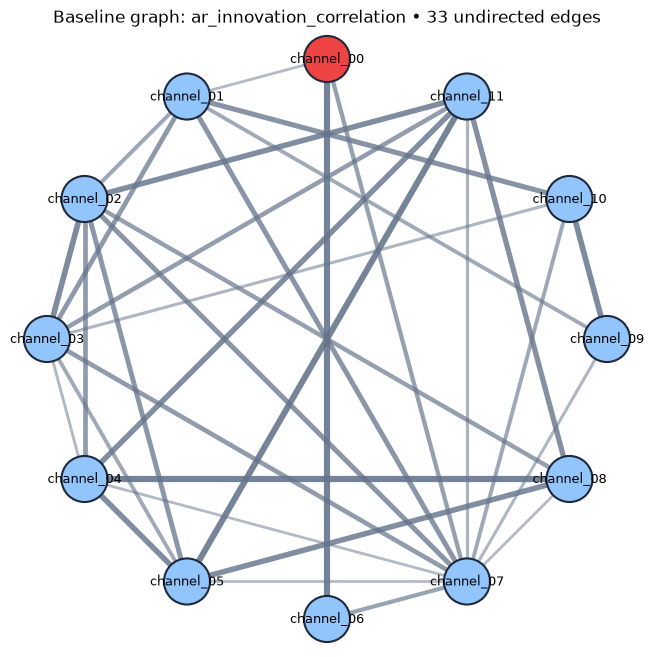

In [5]:
if result.graph is None:
    print("Граф не построен: pipeline строит его только для обнаруженного многоканального события.")
else:
    adjacency = result.graph.adjacency
    dependence = result.graph.dependence
    node_count = len(channel_names)
    angles = np.linspace(0, 2*np.pi, node_count, endpoint=False) + np.pi/2
    positions = np.column_stack([np.cos(angles), np.sin(angles)])
    fig, ax = plt.subplots(figsize=(8, 8))
    for left in range(node_count):
        for right in range(left + 1, node_count):
            if adjacency[left, right]:
                strength = float(dependence[left, right])
                ax.plot(*positions[[left, right]].T, color="#64748b",
                        linewidth=0.5 + 4*strength, alpha=0.25 + 0.65*strength, zorder=1)
    node_colors = ["#ef4444" if node == result.ranking.source else "#93c5fd" for node in range(node_count)]
    ax.scatter(positions[:, 0], positions[:, 1], s=1100, c=node_colors,
               edgecolor="#1e293b", linewidth=1.5, zorder=2)
    for node, name in enumerate(channel_names):
        ax.text(*positions[node], name, ha="center", va="center", fontsize=9, zorder=3)
    edge_count = int(np.triu(adjacency, 1).sum())
    ax.set_title(f"Baseline graph: {result.graph.method} • {edge_count} undirected edges")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

## Как интерпретировать результат

- **Обнаружение:** утверждает, что после baseline возникло устойчивое экстремальное значение агрегированного индикатора относительно fitted tail.
- **Граф:** фиксирует зависимости, оценённые до события; этим ограничивается утечка информации из будущего.
- **Локализация:** сочетает пик, энергию, задержку, степень и отклик соседей. Здесь она совпала с истинным источником — но это проверяемо только потому, что ряд синтетический; в ноутбуке 5 та же логика при `persistence=2` ошибается.
- **Проверка устойчивости:** перед содержательным выводом варьируйте baseline, tail quantile, alarm probability, persistence и метод графа; согласие одного запуска недостаточно.